## 1.Importing Libraries

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix ,ConfusionMatrixDisplay ,accuracy_score ,recall_score ,precision_score ,f1_score)

## 2.Loading Dataset

In [155]:
df = pd.read_csv('Predicting Coupon Acceptance on E-commerce Platforms.csv')

In [156]:
# Quick check the data
df.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,No Urgent Place,Alone,Sunny,55,Restaurant(<20),1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,Coffee House,1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [157]:
df.tail()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
12679,Home,Partner,Rainy,55,Carry out & Take away,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,Carry out & Take away,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,Coffee House,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,Bar,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,1,1,0,1,0
12683,Work,Alone,Sunny,80,Restaurant(20-50),2h,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,1,0,0


## 3.Data Preprocessing

In [158]:
# checking dataset shape 
df.shape

(12684, 25)

In [159]:
# Checking dataset size
df.size

317100

In [160]:
# Checking columns in dataset
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Accept(Y/N?)'],
      dtype='object')

In [161]:
# Checking the Data-Types of the Columns
df.dtypes

destination             object
passanger               object
weather                 object
temperature              int64
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
car                     object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ5min         int64
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Accept(Y/N?)             int64
dtype: object

In [162]:
#Checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   coupon                12684 non-null  object
 5   expiration            12684 non-null  object
 6   gender                12684 non-null  object
 7   age                   12684 non-null  object
 8   maritalStatus         12684 non-null  object
 9   has_children          12684 non-null  int64 
 10  education             12684 non-null  object
 11  occupation            12684 non-null  object
 12  income                12684 non-null  object
 13  car                   108 non-null    object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

In [163]:
# is_claim Is the Target column
# Checking the value counts for number of unique values
df['Accept(Y/N?)'].value_counts()

Accept(Y/N?)
1    7210
0    5474
Name: count, dtype: int64

In [164]:
# Checking the percentage of number of unique values are present
df['Accept(Y/N?)'].value_counts(normalize=True)*100

Accept(Y/N?)
1    56.843267
0    43.156733
Name: proportion, dtype: float64

#### Note1: The Target Column is Balenced

### Checking Missing and Duplicate Data

In [165]:
df.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Accept(Y/N?)                0
dtype: int64

In [166]:
df.duplicated().sum() # 291 duplicated values in datas

291

### Droping Car col. bcz too many null values are in 

In [167]:
df.drop(columns=['car'], axis=1, inplace=True)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   coupon                12684 non-null  object
 5   expiration            12684 non-null  object
 6   gender                12684 non-null  object
 7   age                   12684 non-null  object
 8   maritalStatus         12684 non-null  object
 9   has_children          12684 non-null  int64 
 10  education             12684 non-null  object
 11  occupation            12684 non-null  object
 12  income                12684 non-null  object
 13  Bar                   12577 non-null  object
 14  CoffeeHouse           12467 non-null  object
 15  CarryAway             12533 non-null

### Imputing Missing values / Handling Missing values

In [169]:
# Fill missing values with 'unknown' for categorical and median for numerical
for i in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
    df[i].fillna('unknown', inplace=True)

In [170]:
df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Accept(Y/N?)            0
dtype: int64

### Handling Duplicate data

In [171]:
df.drop_duplicates(inplace=True) # Dropping duplicate values

In [172]:
df.duplicated().sum() # All duplicate data handled/Drop

0

##### Note 2:
##### Zero Missing values
##### Zero Duplicate values

## 4.Sorting Categorical and Numerical columns in list

In [173]:
categorical=[]
numerical=[]

#### Seperating categorical column with Number of unique values

In [174]:
for i in df.select_dtypes(include='object').columns:
    print(i,":",df[i].nunique())
    categorical.append(i)
print("\n\n")
print(categorical)

destination : 3
passanger : 4
weather : 3
coupon : 5
expiration : 2
gender : 2
age : 8
maritalStatus : 5
education : 6
occupation : 25
income : 9
Bar : 6
CoffeeHouse : 6
CarryAway : 6
RestaurantLessThan20 : 6
Restaurant20To50 : 6



['destination', 'passanger', 'weather', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']


#### Separating Categorical and Numerical

In [175]:
categorical = df.select_dtypes(include='O').columns.tolist()
numerical = df.select_dtypes(include=['int','float']).columns.tolist()

print("Categorical columns are: \n",categorical,"\n")
print("Numerical columns are: \n",numerical)

Categorical columns are: 
 ['destination', 'passanger', 'weather', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'] 

Numerical columns are: 
 ['temperature', 'has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Accept(Y/N?)']


In [176]:
for i in df.select_dtypes(include=['int64','float64']).columns:
    print(i,":",df[i].nunique())
    if df[i].nunique()>25:
        numerical.append(i)
    else:
        categorical.append(i)
print("\n\n")
print(numerical)

temperature : 3
has_children : 2
toCoupon_GEQ5min : 1
toCoupon_GEQ15min : 2
toCoupon_GEQ25min : 2
direction_same : 2
direction_opp : 2
Accept(Y/N?) : 2



['temperature', 'has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Accept(Y/N?)']


In [177]:
df['income'].value_counts()

income
$25000 - $37499     1972
$12500 - $24999     1795
$37500 - $49999     1760
$100000 or More     1688
$50000 - $62499     1624
Less than $12500    1013
$87500 - $99999      865
$75000 - $87499      844
$62500 - $74999      832
Name: count, dtype: int64

In [178]:
df['income'].value_counts(normalize=True)*100

income
$25000 - $37499     15.912209
$12500 - $24999     14.483983
$37500 - $49999     14.201565
$100000 or More     13.620592
$50000 - $62499     13.104172
Less than $12500     8.173969
$87500 - $99999      6.979747
$75000 - $87499      6.810296
$62500 - $74999      6.713467
Name: proportion, dtype: float64

In [179]:
df['occupation'].value_counts()

occupation
Unemployed                                   1828
Student                                      1550
Computer & Mathematical                      1360
Sales & Related                              1066
Education&Training&Library                    921
Management                                    806
Office & Administrative Support               631
Arts Design Entertainment Sports & Media      617
Business & Financial                          536
Retired                                       489
Food Preparation & Serving Related            293
Healthcare Support                            237
Healthcare Practitioners & Technical          237
Community & Social Services                   236
Legal                                         218
Transportation & Material Moving              214
Architecture & Engineering                    172
Personal Care & Service                       172
Protective Service                            172
Life Physical Social Science           

In [180]:
df['occupation'].value_counts(normalize=True)*100

occupation
Unemployed                                   14.750262
Student                                      12.507060
Computer & Mathematical                      10.973937
Sales & Related                               8.601630
Education&Training&Library                    7.431615
Management                                    6.503671
Office & Administrative Support               5.091584
Arts Design Entertainment Sports & Media      4.978617
Business & Financial                          4.325022
Retired                                       3.945776
Food Preparation & Serving Related            2.364238
Healthcare Support                            1.912370
Healthcare Practitioners & Technical          1.912370
Community & Social Services                   1.904301
Legal                                         1.759058
Transportation & Material Moving              1.726781
Architecture & Engineering                    1.387880
Personal Care & Service                       1.387880

#### Income group of 2500-37499 Has highest accept For yes
#### Similarly for lowest accept for yes And for no as well

# 5 Exploratory Data Analysis(EDA)

#### A] Categorical EDA

#### Pie chart

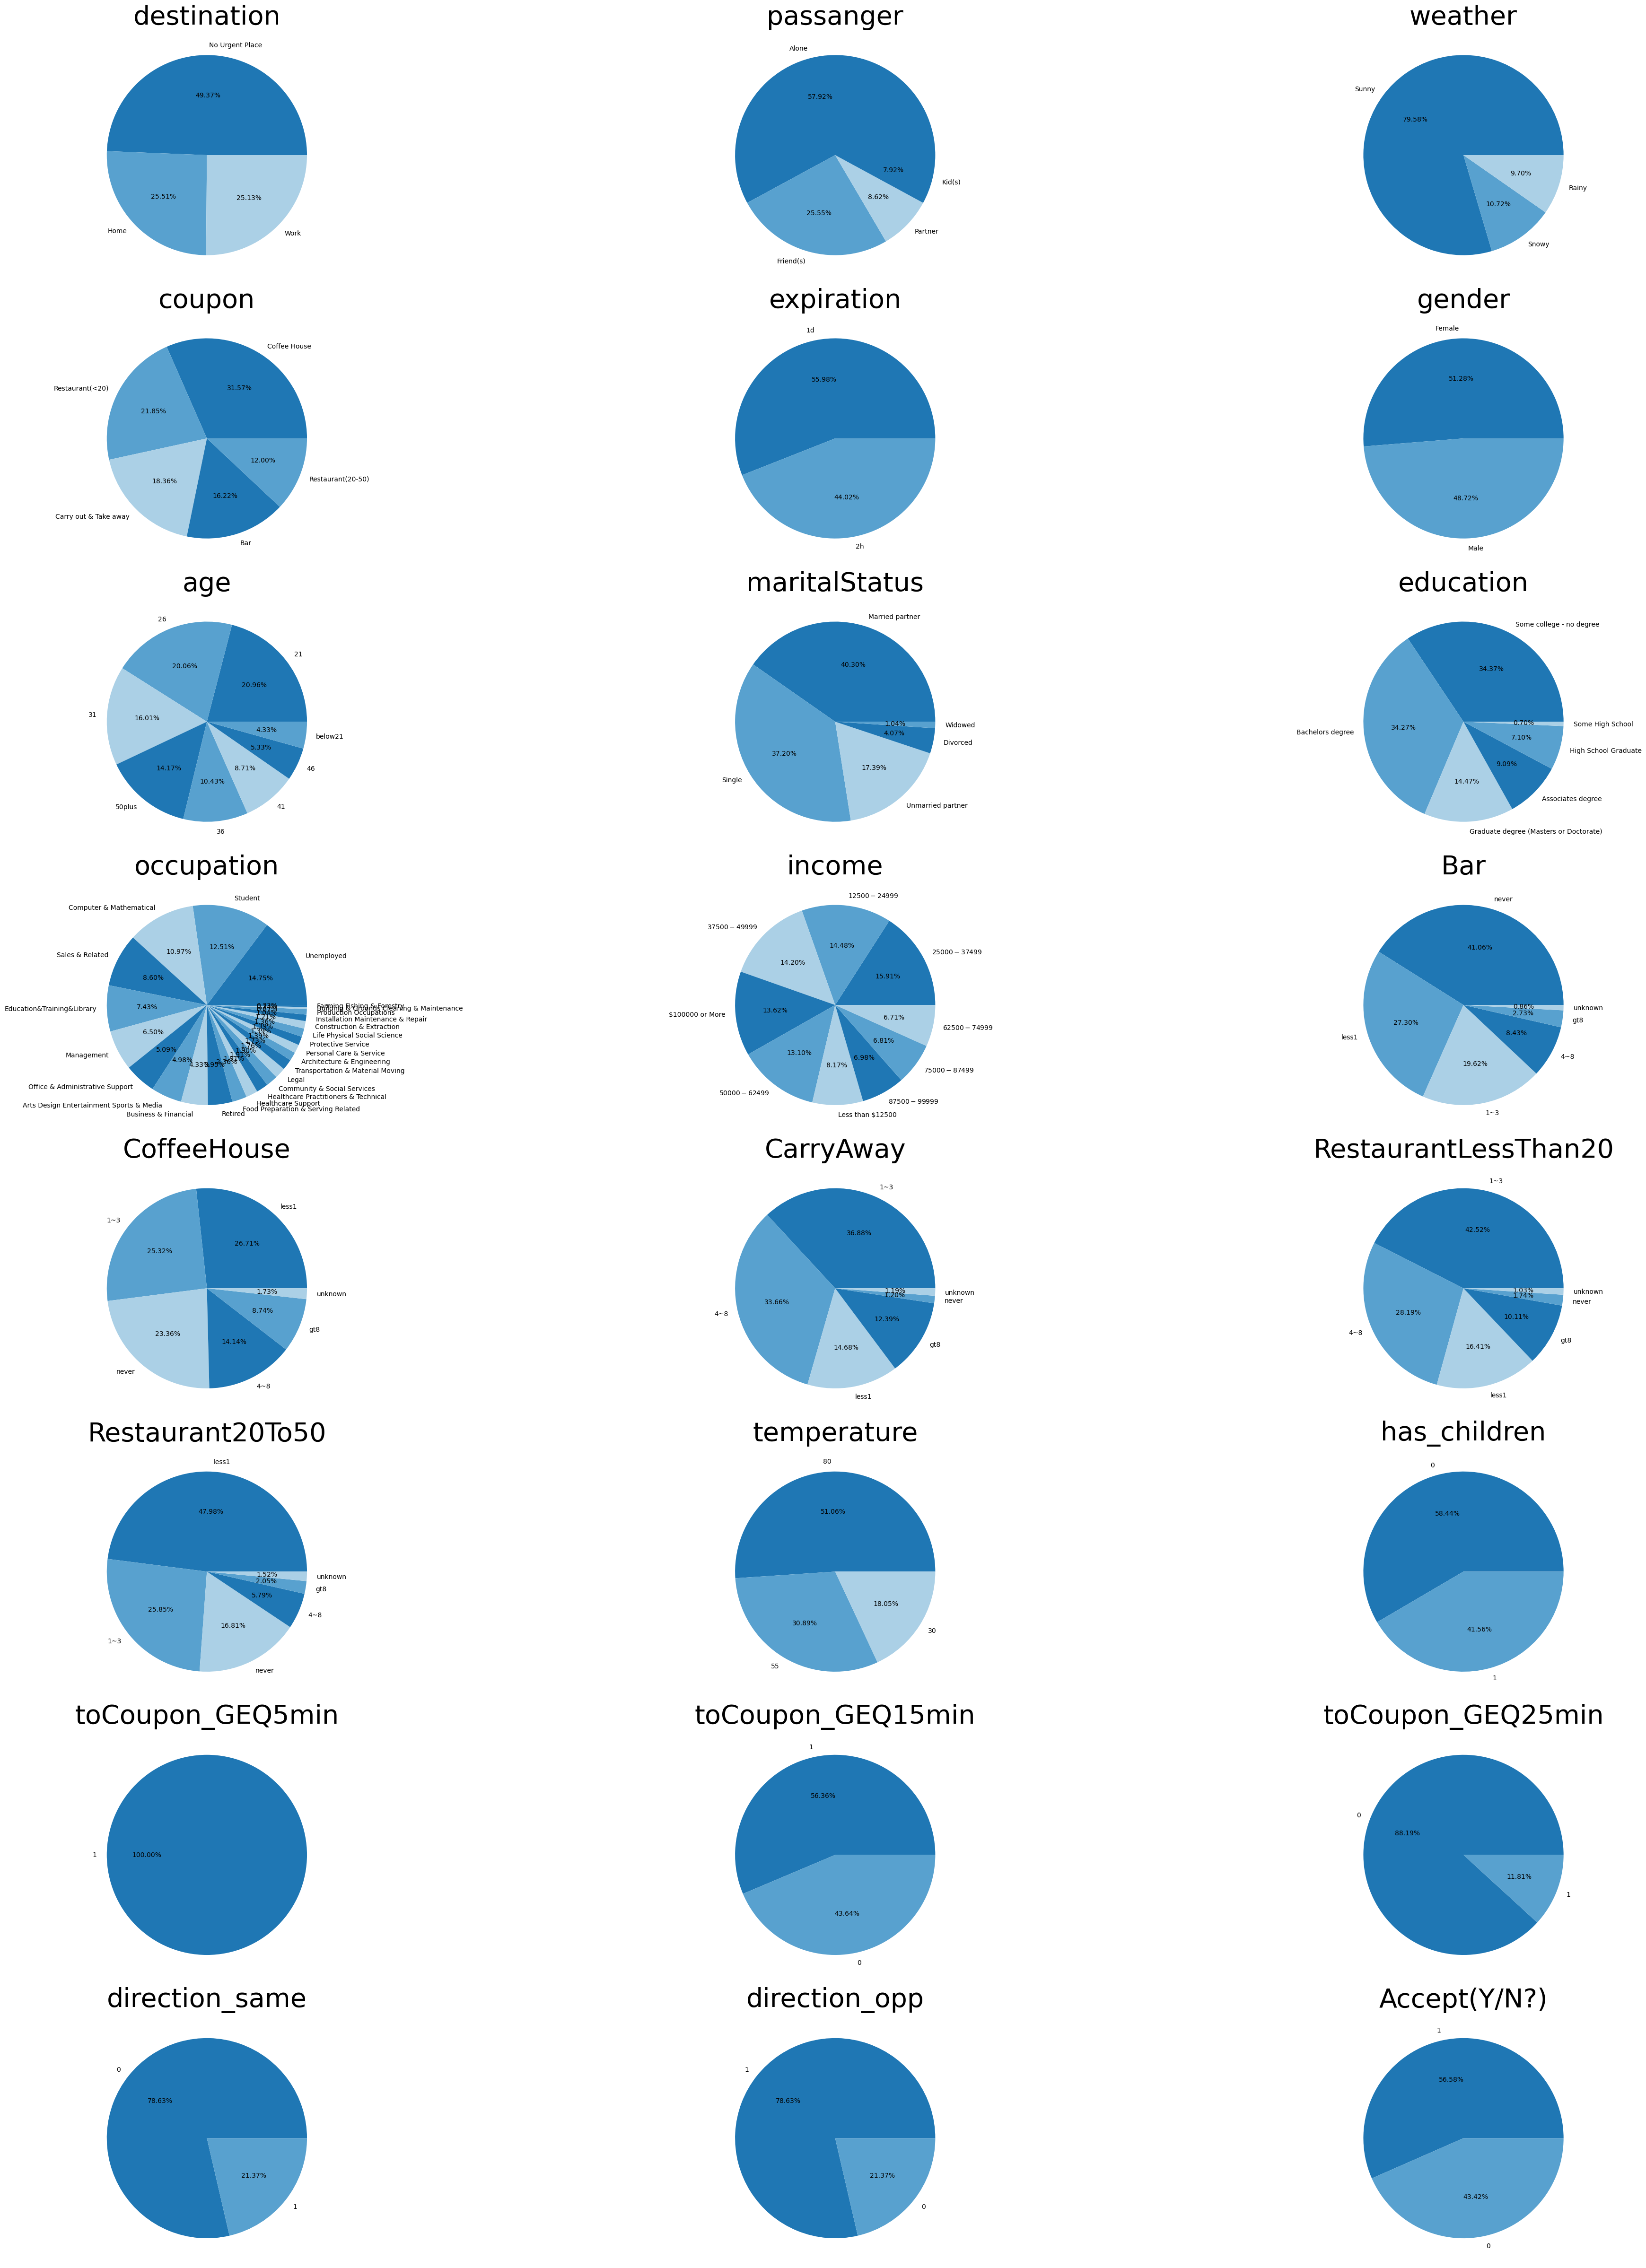

In [181]:
fig=plt.figure(figsize=(40,90))
count=1
for i in categorical:
     if df[i].nunique():
         keys=df[i].value_counts().keys()
         values=df[i].value_counts().values
         plt.subplot(15,3,count)
         plt.pie(x=values, labels=keys, autopct='%0.2f%%')
         plt.title(i, fontsize=40)
         fig.tight_layout()
         count+=1
plt.show()

#### Count Plot

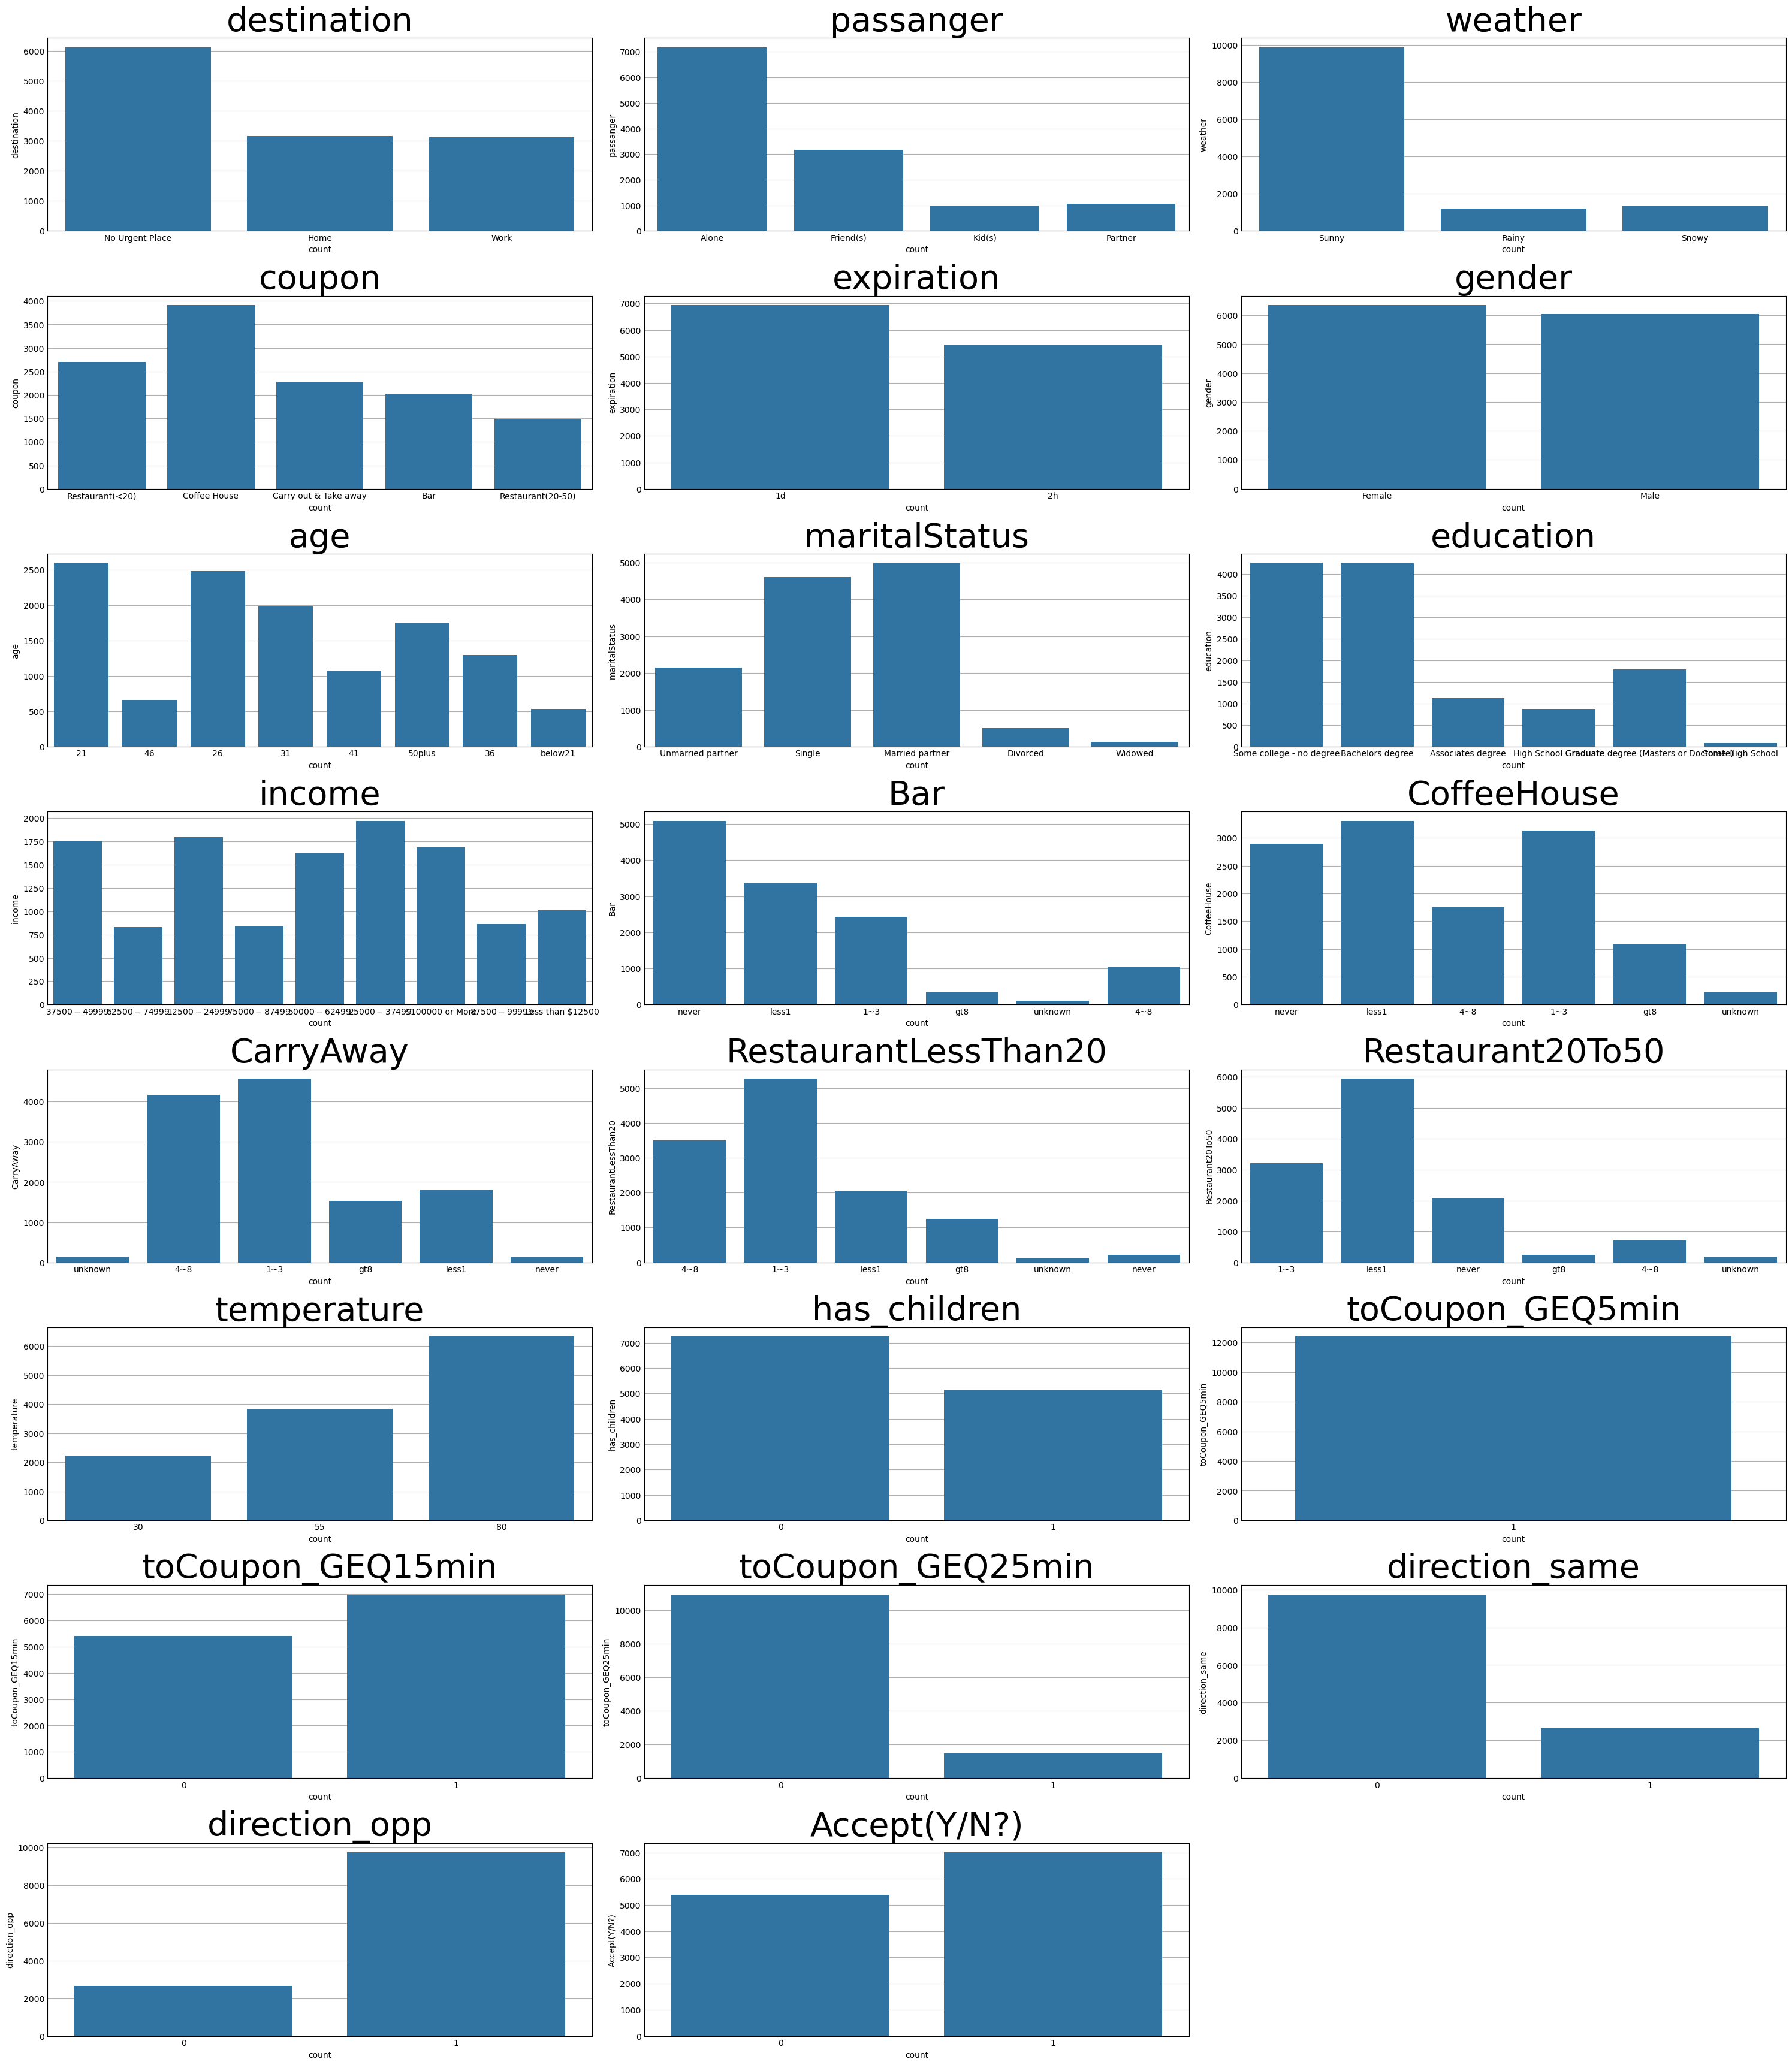

In [182]:
# Example countplot for a single categorical variable
count=1
fig=plt.figure(figsize=(30,60))
for i in categorical:
     if df[i].nunique()<25:
         plt.subplot(14,3,count)
         sns.countplot(x=i, data=df,)
         plt.title(i, fontsize=40) 
         plt.xlabel('count')
         plt.ylabel(i)
         fig.tight_layout() 
         count+=1 
plt.show()

#### Stem plot

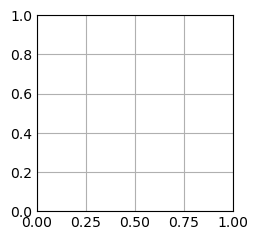

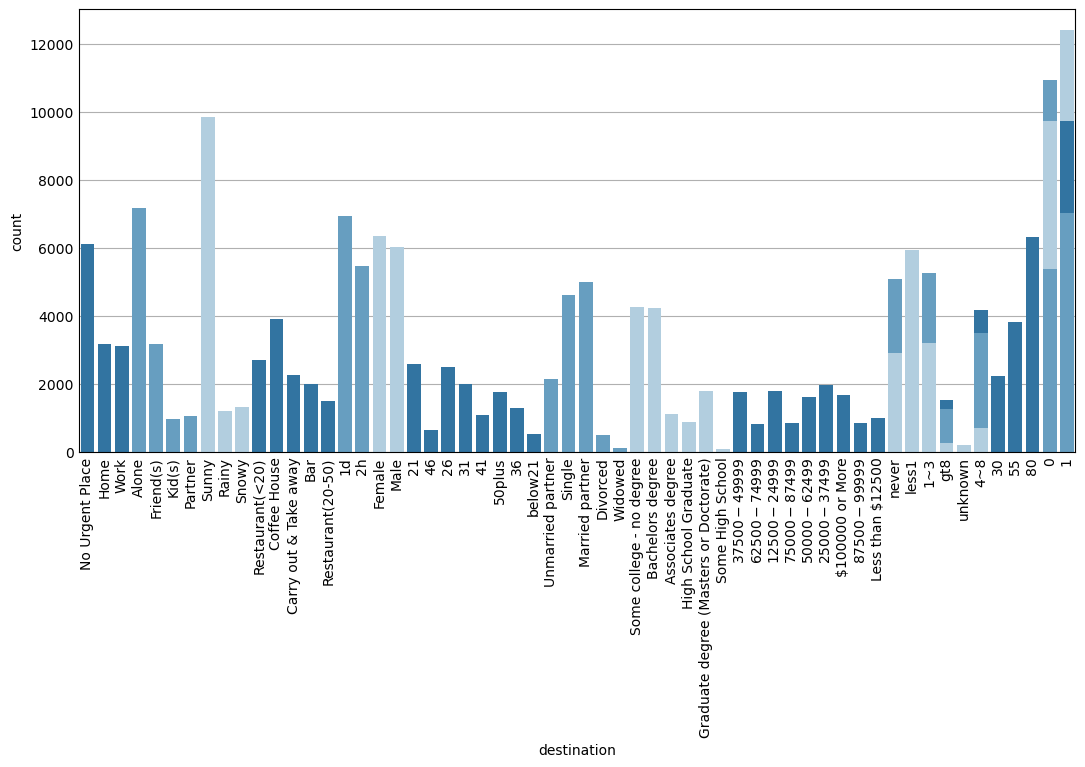

In [183]:
plt.style.use('_mpl-gallery')

# make data
#x = 0.5 + np.arange(8)
#y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()
count=1
fig=plt.figure(figsize=(120,140))
for i in categorical:   
    if df[i].nunique() <=11:
        plt.subplot(26,10,count)
        sns.countplot(x=i, data=df,)
        plt.xticks(rotation=90)
       
plt.show()

In [184]:
# Counting no.of unique values in every catogarical columns
df[categorical].nunique()

destination              3
passanger                4
weather                  3
coupon                   5
expiration               2
gender                   2
age                      8
maritalStatus            5
education                6
occupation              25
income                   9
Bar                      6
CoffeeHouse              6
CarryAway                6
RestaurantLessThan20     6
Restaurant20To50         6
temperature              3
has_children             2
toCoupon_GEQ5min         1
toCoupon_GEQ15min        2
toCoupon_GEQ25min        2
direction_same           2
direction_opp            2
Accept(Y/N?)             2
dtype: int64

In [185]:
# checking unique values of categorical columns which are less than 25
for i in categorical:
    if df[i].nunique()<25:
        print(i,df[i].unique(),end="\n\n")

destination ['No Urgent Place' 'Home' 'Work']

passanger ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']

weather ['Sunny' 'Rainy' 'Snowy']

coupon ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']

expiration ['1d' '2h']

gender ['Female' 'Male']

age ['21' '46' '26' '31' '41' '50plus' '36' 'below21']

maritalStatus ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']

education ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']

income ['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
 '$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']

Bar ['never' 'less1' '1~3' 'gt8' 'unknown' '4~8']

CoffeeHouse ['never' 'less1' '4~8' '1~3' 'gt8' 'unknown']

CarryAway ['unknown' '4~8' '1~3' 'gt8' 'less1' 'never']

RestaurantLessThan20 ['4~8' '1~3' 'less1' 'gt8' 'unknown' 'never']

Restaur

#### Count plot with hue of target column(target_col= 'Accept(Y/N?)')

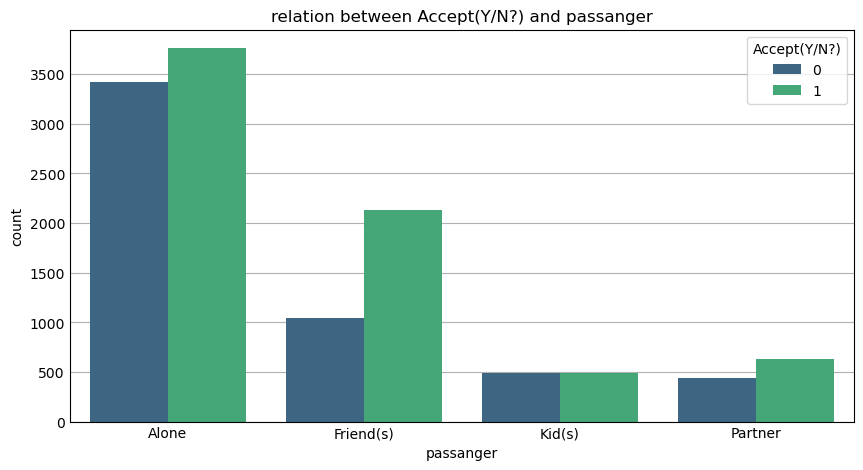

In [186]:
# Count plot with hue of target column
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "passanger" , hue ="Accept(Y/N?)", palette='viridis')
plt.title("relation between Accept(Y/N?) and passanger")
plt.show()

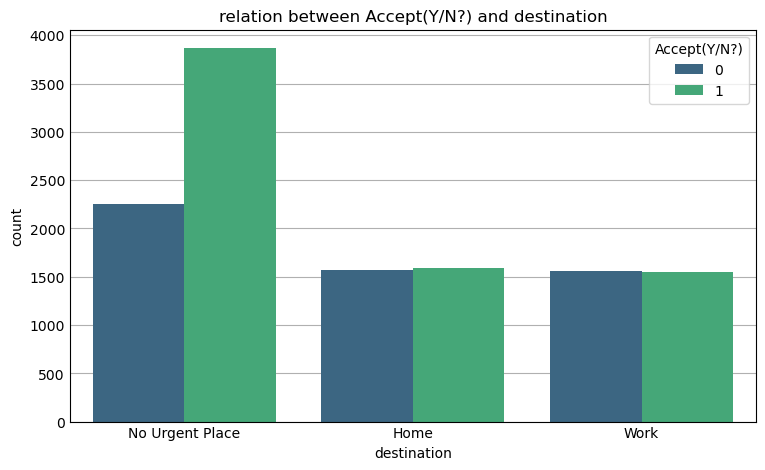

In [187]:
plt.figure(figsize=(7,4))
sns.countplot(data = df ,x= "destination" , hue ="Accept(Y/N?)", palette='viridis')
plt.title("relation between Accept(Y/N?) and destination")
plt.show()

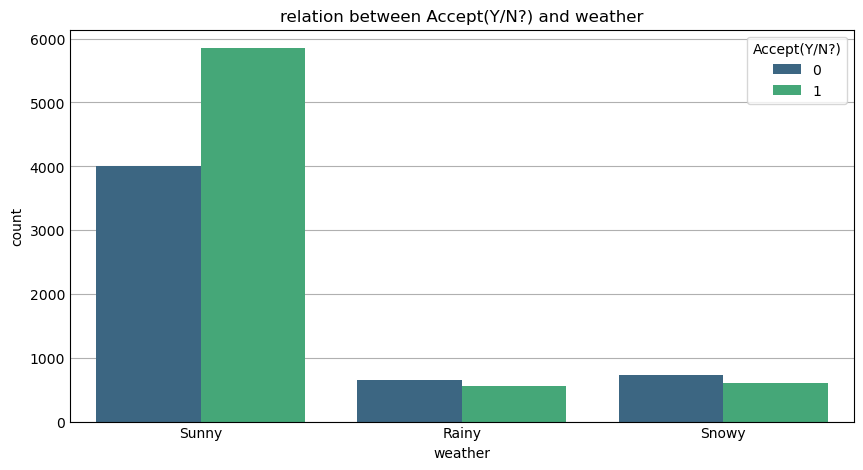

In [188]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "weather" , hue ="Accept(Y/N?)", palette='viridis')
plt.title("relation between Accept(Y/N?) and weather")
plt.show()

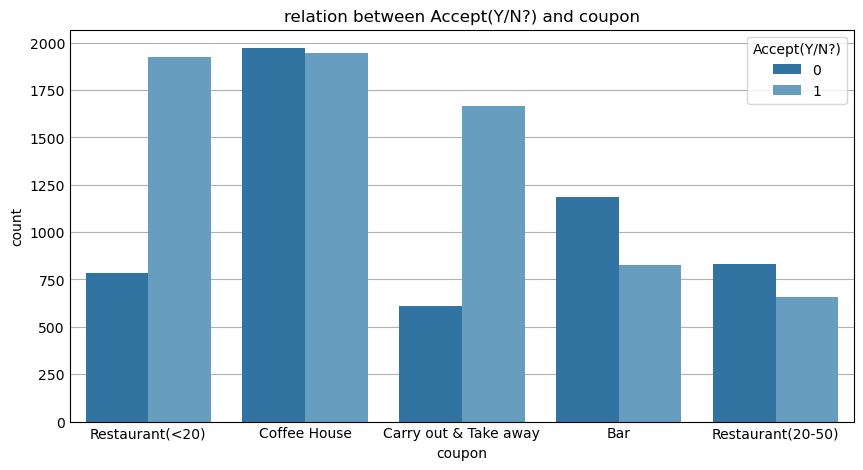

In [189]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "coupon" , hue ="Accept(Y/N?)",)
plt.title("relation between Accept(Y/N?) and coupon")
plt.show()

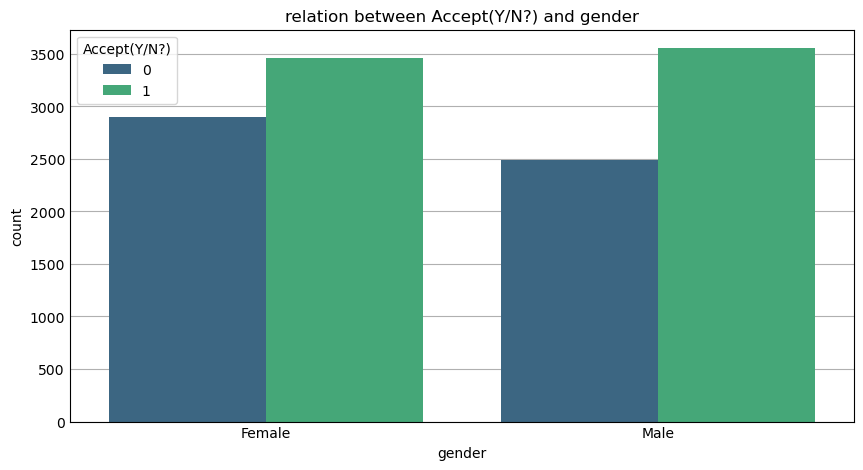

In [190]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "gender" , hue ="Accept(Y/N?)", palette='viridis')
plt.title("relation between Accept(Y/N?) and gender")
plt.show()

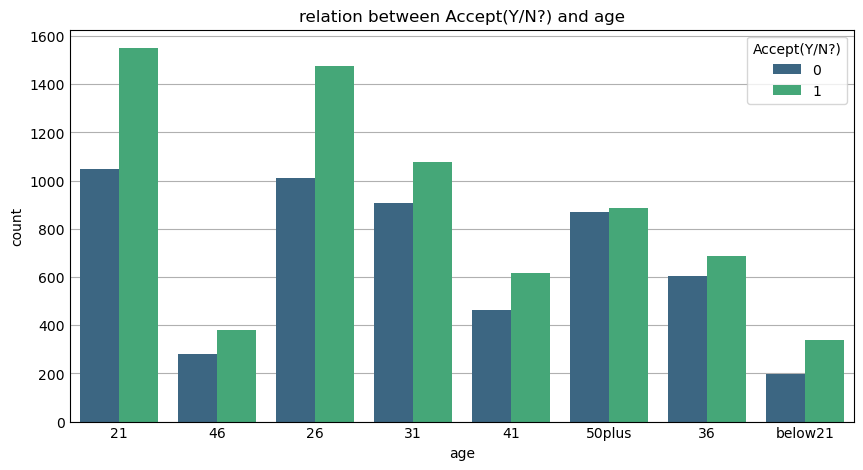

In [191]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "age" , hue ="Accept(Y/N?)", palette='viridis')
plt.title("relation between Accept(Y/N?) and age")
plt.show()

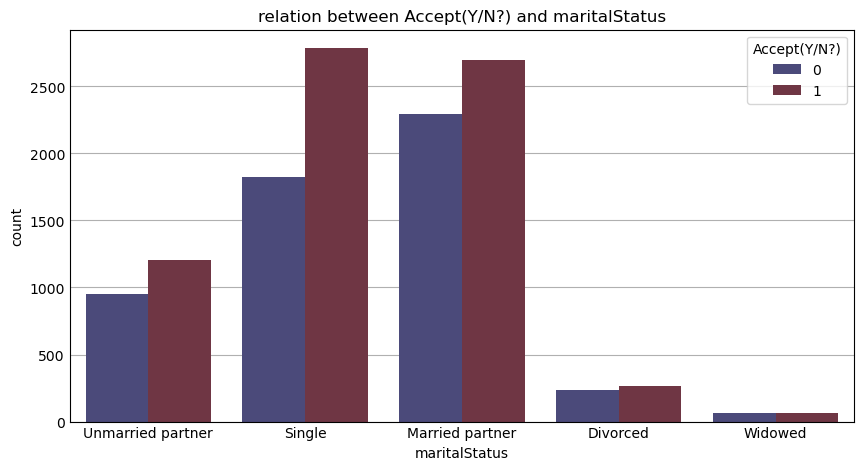

In [192]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "maritalStatus" , hue ="Accept(Y/N?)", palette='icefire')
plt.title("relation between Accept(Y/N?) and maritalStatus")
plt.show()

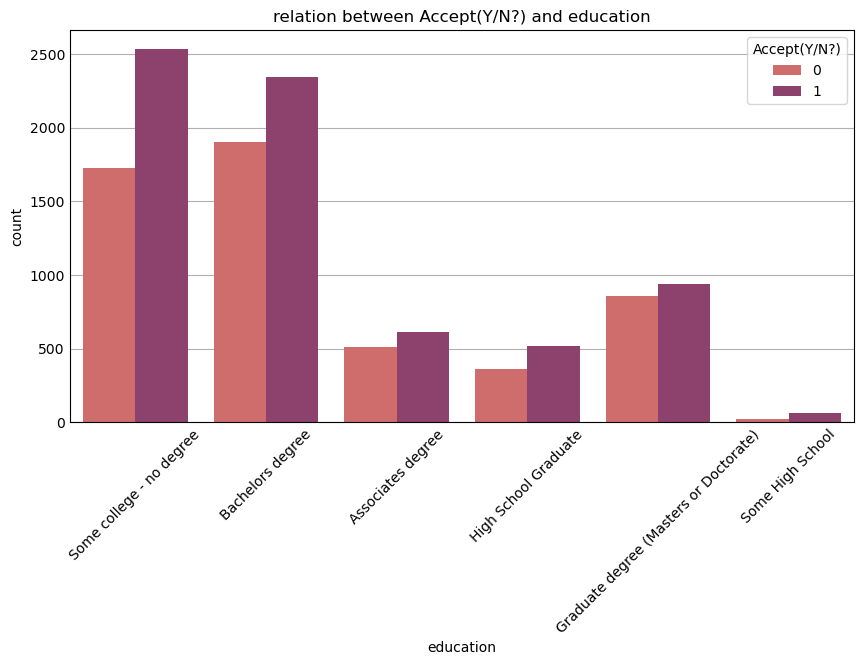

In [193]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "education" , hue ="Accept(Y/N?)", palette='flare')
plt.title("relation between Accept(Y/N?) and education")
plt.xticks(rotation=45)
plt.show()

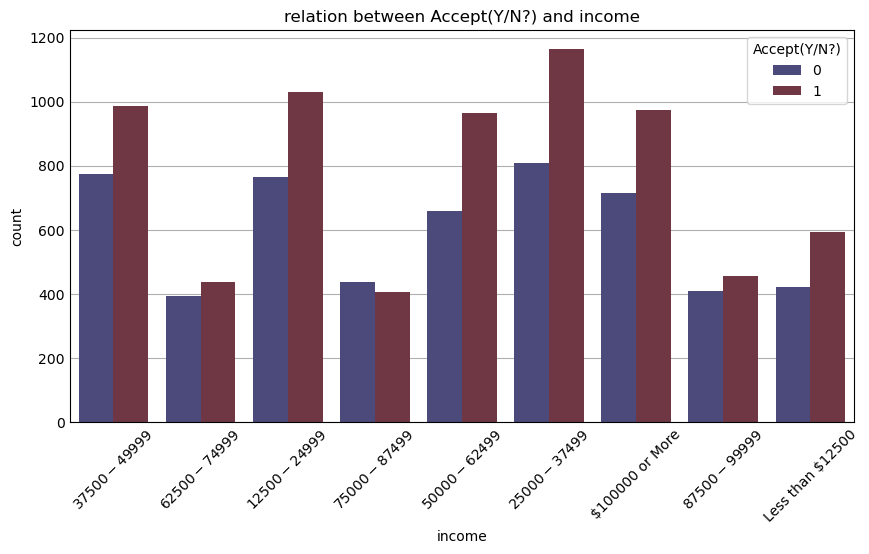

In [194]:
plt.figure(figsize=(8,4))
sns.countplot(data = df ,x= "income" , hue ="Accept(Y/N?)", palette='icefire')
plt.title("relation between Accept(Y/N?) and income")
plt.xticks(rotation=45)
plt.show()

### B] Numerical EDA

### Box Plot

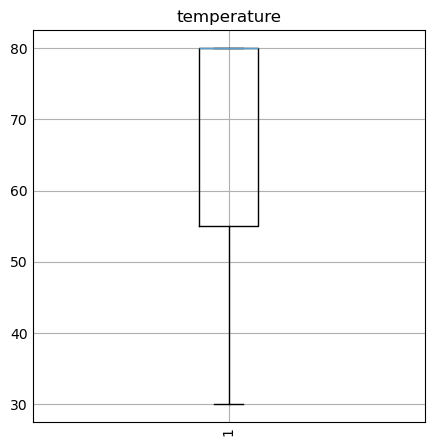

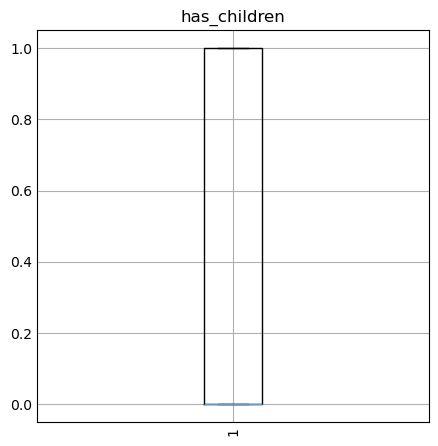

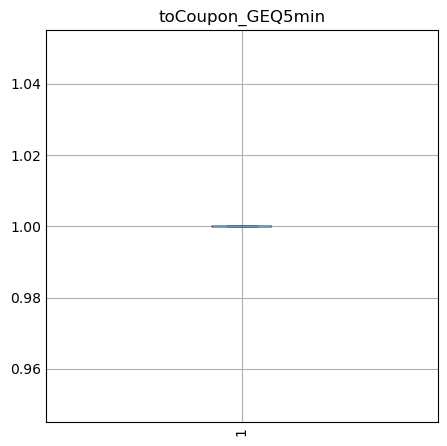

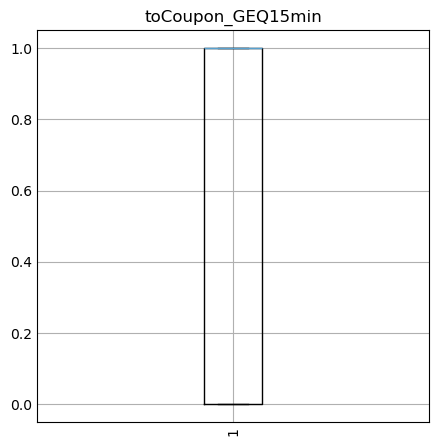

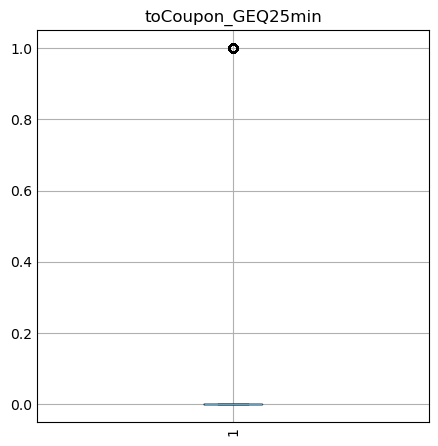

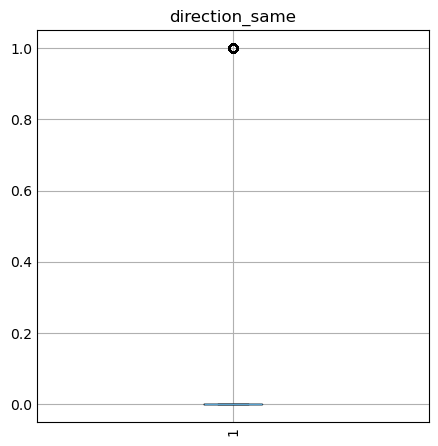

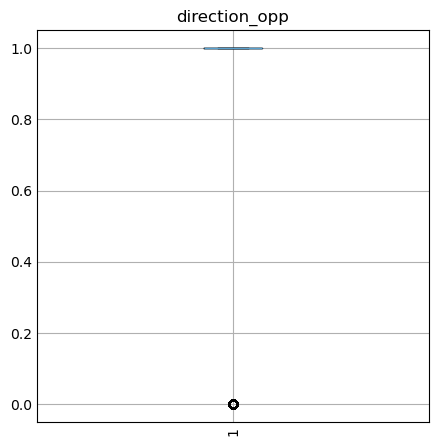

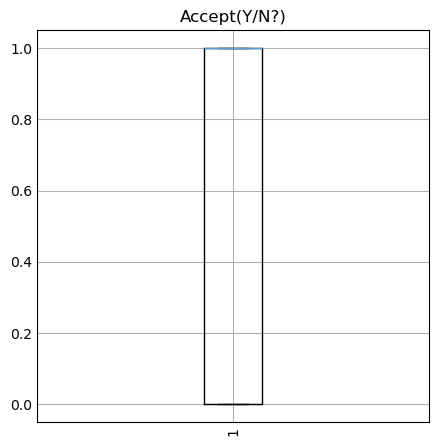

In [195]:
# whole numerical col. visulizing in boxplot
for i in numerical:
   # if df[i].nunique()<1000:
        
       plt.figure(figsize=(4,4))
       plt.title(i) 
       plt.boxplot(x=i, data=df)
       plt.xticks(rotation=90)
plt.show()

#### There are none outliers in Boxplot

In [196]:
df[numerical].describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
count,12393.000000,12393.000000,12393.0,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000
mean,63.252643,0.415557,1.0,0.563625,0.118051,0.213750,0.786250,0.565803
std,19.075396,0.492838,0.0,0.495955,0.322681,0.409969,0.409969,0.495671
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


### Histogram

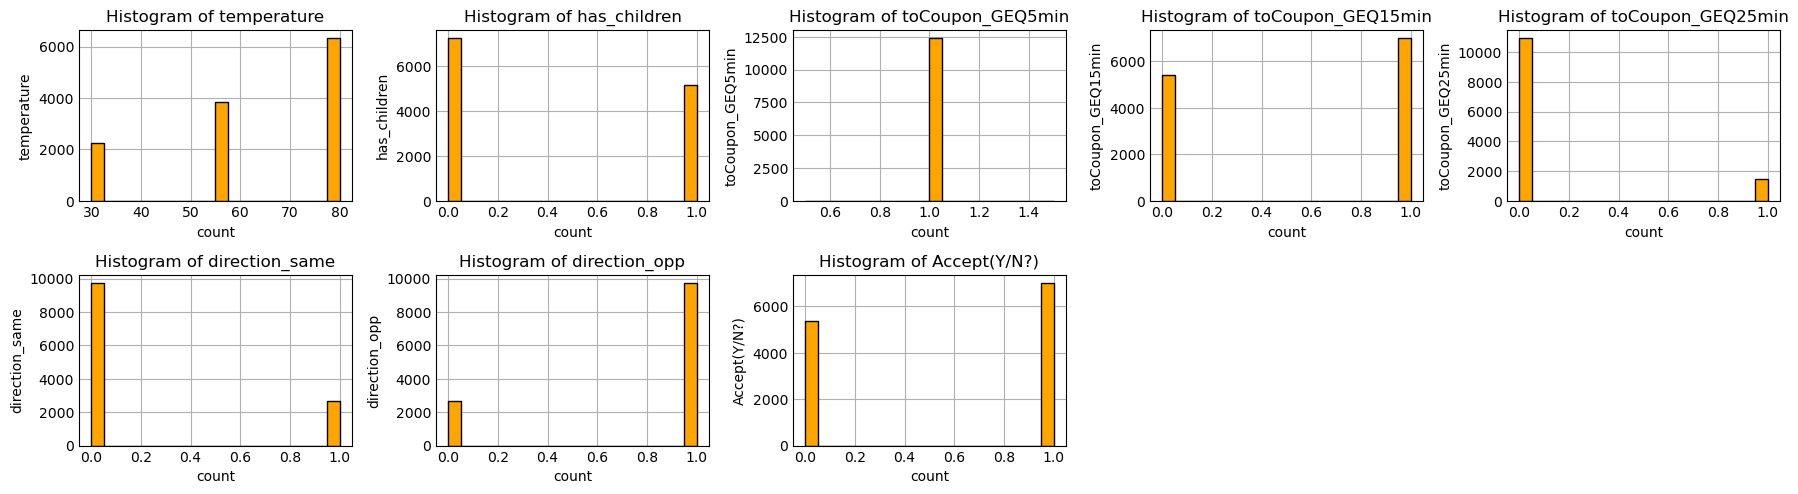

In [197]:
plt.figure(figsize=(18, 12))
for idx, i in enumerate(numerical):
    plt.subplot(5, 5, idx + 1)  # Adjust grid size (5x5) based on number of numerical columns
    plt.hist(df[i], bins=20, color='orange', edgecolor='black')
    plt.title(f'Histogram of {i}')
    plt.xlabel('count')
    plt.ylabel(i)
plt.tight_layout()
plt.show()

### KDE Plot

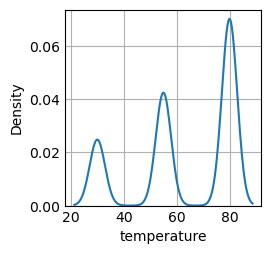

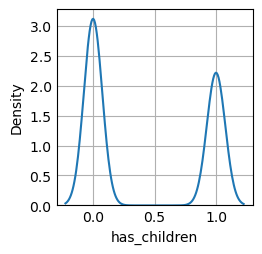

C:\Users\Welcome\AppData\Local\Temp\ipykernel_12880\2305473507.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df[i])


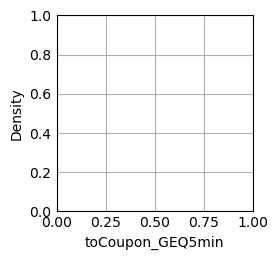

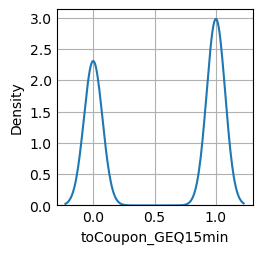

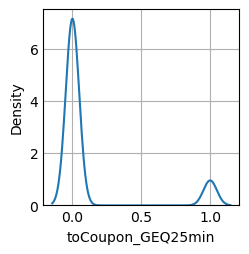

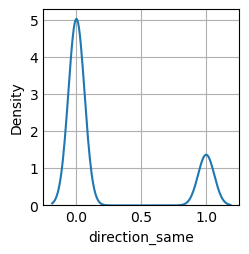

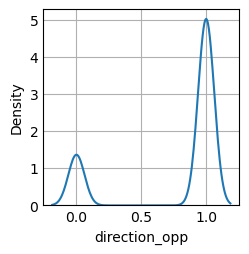

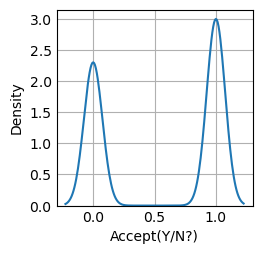

In [198]:
for i in numerical:
    if df[i].nunique() < 1000:
        sns.kdeplot(data=df[i])
        plt.show()  

#### Correlation matrix of numerical column

In [199]:
df[numerical].corr()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
temperature,1.000000,-0.016963,NaN,-0.141124,-0.230067,0.088885,-0.088885,0.064074
has_children,-0.016963,1.000000,NaN,0.078686,-0.011651,-0.032276,0.032276,-0.044889
toCoupon_GEQ5min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toCoupon_GEQ15min,-0.141124,0.078686,NaN,1.000000,0.321919,-0.297284,0.297284,-0.086050
toCoupon_GEQ25min,-0.230067,-0.011651,NaN,0.321919,1.000000,-0.190759,0.190759,-0.107855
direction_same,0.088885,-0.032276,NaN,-0.297284,-0.190759,1.000000,-1.000000,0.016356
direction_opp,-0.088885,0.032276,NaN,0.297284,0.190759,-1.000000,1.000000,-0.016356
Accept(Y/N?),0.064074,-0.044889,NaN,-0.086050,-0.107855,0.016356,-0.016356,1.000000


In [200]:
df['toCoupon_GEQ5min'].isnull().sum()

0

In [201]:
df['toCoupon_GEQ5min'].dtype

dtype('int64')

In [202]:
df['toCoupon_GEQ5min'].nunique()

1

In [203]:
df[numerical].nunique()

temperature          3
has_children         2
toCoupon_GEQ5min     1
toCoupon_GEQ15min    2
toCoupon_GEQ25min    2
direction_same       2
direction_opp        2
Accept(Y/N?)         2
dtype: int64

#### Dropping 'toCoupon_GEQ5min' because there is nan values in column 

In [204]:
df.drop(columns=['toCoupon_GEQ5min'], axis=1, inplace=True)

In [205]:
print(df.columns) ## checking the column is it drop or not..

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Accept(Y/N?)'],
      dtype='object')


In [206]:
numerical = [col for col in df.select_dtypes(include=['int64', 'float64']).columns]
print(numerical)  # Ensure 'toCoupon_GEQ5min' is not in this list


['temperature', 'has_children', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Accept(Y/N?)']


In [207]:
df[numerical].corr()

,temperature,has_children,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
temperature,1.000000,-0.016963,-0.141124,-0.230067,0.088885,-0.088885,0.064074
has_children,-0.016963,1.000000,0.078686,-0.011651,-0.032276,0.032276,-0.044889
toCoupon_GEQ15min,-0.141124,0.078686,1.000000,0.321919,-0.297284,0.297284,-0.086050
toCoupon_GEQ25min,-0.230067,-0.011651,0.321919,1.000000,-0.190759,0.190759,-0.107855
direction_same,0.088885,-0.032276,-0.297284,-0.190759,1.000000,-1.000000,0.016356
direction_opp,-0.088885,0.032276,0.297284,0.190759,-1.000000,1.000000,-0.016356
Accept(Y/N?),0.064074,-0.044889,-0.086050,-0.107855,0.016356,-0.016356,1.000000


In [208]:
df.isnull().sum() # Checking Null values again

destination             0
passanger               0
weather                 0
temperature             0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Accept(Y/N?)            0
dtype: int64

#### KDE plot after removing nan values col.

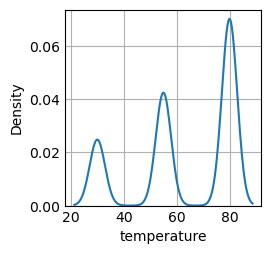

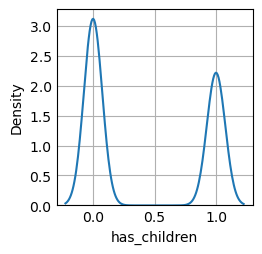

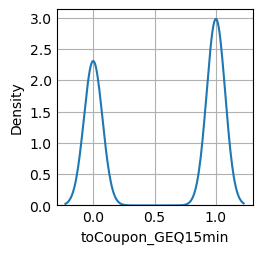

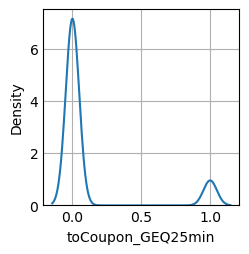

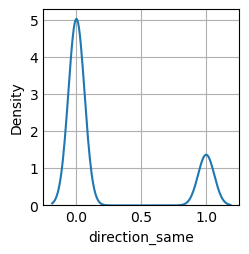

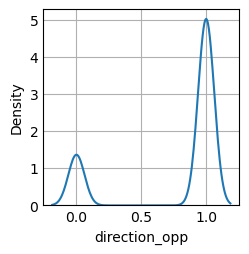

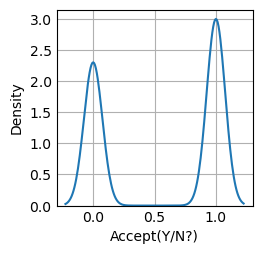

In [209]:
for i in numerical:
    if df[i].nunique():
        sns.kdeplot(data=df[i])
        plt.show()

### Heatmap

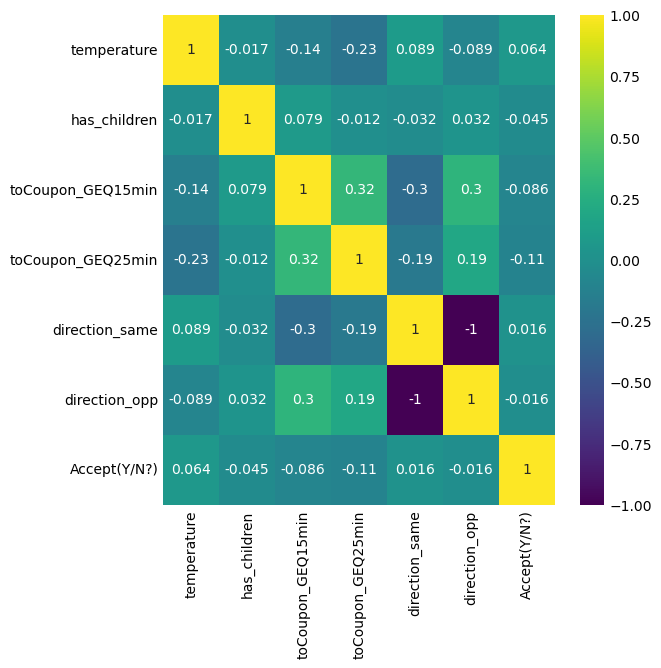

In [243]:
plt.figure(figsize=(5,5))
sns.heatmap(data=df[numerical].corr(),cmap='viridis',vmin=-1,vmax=1,annot=True)
plt.show()

### 6 Lable encoding

In [211]:
from sklearn.preprocessing import LabelEncoder

In [212]:
le=LabelEncoder()

In [213]:
df2=pd.DataFrame()
for i in df.columns:
      df2[i]=le.fit_transform(df[i])
df2

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,1,0,2,1,4,0,0,0,3,1,...,4,4,5,1,0,0,0,0,1,1
1,1,1,2,2,2,1,0,0,3,1,...,4,4,5,1,0,0,0,0,1,0
2,1,1,2,2,1,1,0,0,3,1,...,4,4,5,1,0,1,0,0,1,1
3,1,1,2,2,2,1,0,0,3,1,...,4,4,5,1,0,1,0,0,1,0
4,1,1,2,2,2,0,0,0,3,1,...,4,4,5,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12388,0,3,0,1,1,0,1,1,2,0,...,4,4,0,1,0,0,0,1,0,1
12389,2,0,0,1,1,0,1,1,2,0,...,4,4,0,1,0,0,0,0,1,1
12390,2,0,1,0,2,0,1,1,2,0,...,4,4,0,1,0,0,0,1,0,0
12391,2,0,1,0,0,0,1,1,2,0,...,4,4,0,1,0,1,1,0,1,0


### 7 X&Y Train Test split

In [214]:
x=df2.drop(columns=['Accept(Y/N?)'],axis=1)
y=df2['Accept(Y/N?)']

In [215]:
x.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp
0,1,0,2,1,4,0,0,0,3,1,...,3,4,4,5,1,0,0,0,0,1
1,1,1,2,2,2,1,0,0,3,1,...,3,4,4,5,1,0,0,0,0,1
2,1,1,2,2,1,1,0,0,3,1,...,3,4,4,5,1,0,1,0,0,1
3,1,1,2,2,2,1,0,0,3,1,...,3,4,4,5,1,0,1,0,0,1
4,1,1,2,2,2,0,0,0,3,1,...,3,4,4,5,1,0,1,0,0,1


In [216]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Accept(Y/N?), dtype: int64

In [217]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [218]:
x_train.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp
3288,2,0,2,2,3,0,1,3,1,1,...,0,3,1,0,0,3,1,0,0,1
10934,0,0,1,0,2,1,1,7,3,0,...,2,4,4,0,3,4,1,0,0,1
9835,2,0,0,1,1,1,0,3,1,1,...,7,0,1,1,1,0,1,0,1,0
7660,2,0,0,1,3,0,0,6,2,1,...,3,3,1,0,0,0,1,1,0,1
1691,1,2,2,2,1,1,0,1,1,1,...,4,4,3,0,0,4,1,0,0,1


In [219]:
x_test.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp
10146,1,0,0,1,2,0,0,0,2,0,...,8,0,1,2,2,1,1,0,0,1
9834,2,0,2,0,0,0,0,3,1,1,...,7,0,1,1,1,0,1,0,1,0
6902,0,0,2,0,1,1,1,1,1,0,...,3,3,3,0,0,3,1,0,1,0
2145,1,1,2,2,4,1,1,0,2,0,...,0,1,2,1,2,0,1,0,0,1
2344,0,0,2,1,3,0,0,0,2,0,...,2,1,3,2,0,0,1,0,0,1


In [220]:
y_train.head()

3288     0
10934    0
9835     1
7660     1
1691     1
Name: Accept(Y/N?), dtype: int64

In [221]:
y_test.head()

10146    1
9834     1
6902     1
2145     1
2344     1
Name: Accept(Y/N?), dtype: int64

## 8 Model Building

### Logistic Regression

In [222]:
lr=LogisticRegression()

In [223]:
lr.fit(x_train,y_train)
y_train_predict_lr=lr.predict(x_train)
y_test_predict_lr=lr.predict(x_test)

In [224]:
print("train")
print(f"accuracy_score{accuracy_score(y_train,y_train_predict_lr)},precision_score{precision_score(y_train,y_train_predict_lr)},recall_score{recall_score(y_train,y_train_predict_lr)}")

train
accuracy_score0.6301190236029857,precision_score0.6461538461538462,recall_score0.7740563530037214


In [225]:
print("test")
print(f"accuracy_score{accuracy_score(y_test,y_test_predict_lr)},precision_score{precision_score(y_test,y_test_predict_lr)},recall_score{recall_score(y_test,y_test_predict_lr)}")

test
accuracy_score0.6232351754739814,precision_score0.6275659824046921,recall_score0.7815924032140248


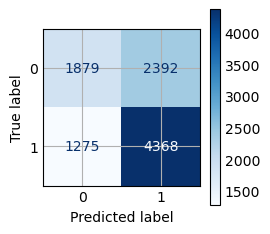

In [244]:
cm = confusion_matrix(y_train,y_train_predict_lr )
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

### Decision Tree

recall acc for train :  0.6605586194627291
precision for train :  0.6579833421938686
f1_score for train :  0.6592684659090909
accuracy :  0.6128706879160782


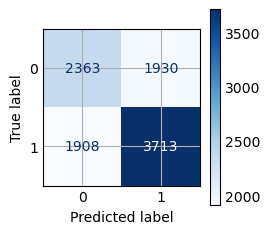

In [226]:
DTC =DecisionTreeClassifier(max_depth=2,criterion='entropy')
DTC.fit(x_train,y_train)

y_pred_train = DTC.predict(x_train)
cm = confusion_matrix(y_pred_train,y_train )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_train,y_train))
print("precision for train : " ,precision_score(y_pred_train,y_train))
print("f1_score for train : " ,f1_score(y_pred_train,y_train))
print("accuracy : " ,accuracy_score(y_pred_train,y_train))
disp.plot(cmap='Blues')

plt.show()

recall acc for test :  0.645587213342599
precision for test :  0.6785975164353543
f1_score for test :  0.6616809116809116
accuracy :  0.6167809600645422


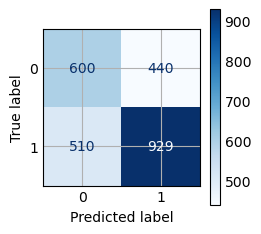

In [227]:
y_pred_test = DTC.predict(x_test)
cm = confusion_matrix(y_pred_test,y_test )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for test : " , recall_score(y_pred_test,y_test))
print("precision for test : " ,  precision_score(y_pred_test,y_test))
print("f1_score for test : " ,   f1_score(y_pred_test,y_test))
print("accuracy : " ,accuracy_score(y_pred_test,y_test))

disp.plot(cmap='Blues')

plt.show()

### Random Forest Clasifier

In [228]:
for i in range(5,105,5):
    rfc=RandomForestClassifier(n_estimators=i,criterion = 'entropy',max_depth=8,random_state=42)
    rfc.fit(x_train,y_train)
    y_train_predict=rfc.predict(x_train)
    y_test_predict=rfc.predict(x_test)
    print("n_estimator =",i)
    print("train")
    print(f"accuracy_score={accuracy_score(y_train,y_train_predict)},precision_score={precision_score(y_train,y_train_predict)},recall_score={recall_score(y_train,y_train_predict)}")
    print("test")
    print(f"accuracy_score={accuracy_score(y_test,y_test_predict)},precision_score={precision_score(y_test,y_test_predict)},recall_score={recall_score(y_test,y_test_predict)}")
    print("")

n_estimator = 5
train
accuracy_score=0.739560217873714,precision_score=0.7251728703839929,recall_score=0.873471557682084
test
accuracy_score=0.672045179507866,precision_score=0.6581342434584755,recall_score=0.8451424397370343

n_estimator = 10
train
accuracy_score=0.7479322170667743,precision_score=0.7252148997134671,recall_score=0.8970405812511075
test
accuracy_score=0.6926179911254539,precision_score=0.670601461495222,recall_score=0.8714390065741418

n_estimator = 15
train
accuracy_score=0.7489408916683478,precision_score=0.7252857142857143,recall_score=0.899698741804005
test
accuracy_score=0.6942315449778136,precision_score=0.6701949860724234,recall_score=0.8787436084733382

n_estimator = 20
train
accuracy_score=0.751866048012911,precision_score=0.7276498355027893,recall_score=0.9014708488392699
test
accuracy_score=0.7006857603872529,precision_score=0.6778218944980148,recall_score=0.872899926953981

n_estimator = 25
train
accuracy_score=0.7563042162598346,precision_score=0.731591789

In [229]:
for i in range(5,105,5):
    rfc=RandomForestClassifier(n_estimators=i,criterion = 'gini',max_depth=7,random_state=42)
    rfc.fit(x_train,y_train)
    y_train_predict=rfc.predict(x_train)
    y_test_predict=rfc.predict(x_test)
    print("n_estimator =",i)
    print("train")
    print(f"accuracy_score={accuracy_score(y_train,y_train_predict)},precision_score={precision_score(y_train,y_train_predict)},recall_score={recall_score(y_train,y_train_predict)}")
    print("test")
    print(f"accuracy_score={accuracy_score(y_test,y_test_predict)},precision_score={precision_score(y_test,y_test_predict)},recall_score={recall_score(y_test,y_test_predict)}")
    print("")

n_estimator = 5
train
accuracy_score=0.711014726649183,precision_score=0.700201787258576,recall_score=0.860889597731703
test
accuracy_score=0.6692214602662364,precision_score=0.6583958453548759,recall_score=0.83345507669832

n_estimator = 10
train
accuracy_score=0.7218075448860197,precision_score=0.7017764722338788,recall_score=0.8890660995924153
test
accuracy_score=0.6829366680112948,precision_score=0.6627582356225572,recall_score=0.8670562454346238

n_estimator = 15
train
accuracy_score=0.7241274964696389,precision_score=0.7024505708716235,recall_score=0.8940279992911572
test
accuracy_score=0.6797095603065753,precision_score=0.6584022038567493,recall_score=0.872899926953981

n_estimator = 20
train
accuracy_score=0.7276578575751462,precision_score=0.706700379266751,recall_score=0.8915470494417863
test
accuracy_score=0.6873739411052844,precision_score=0.6639072847682119,recall_score=0.8787436084733382

n_estimator = 25
train
accuracy_score=0.7297760742384507,precision_score=0.707272727

#### Note:  rfc=RandomForestClassifier(n_estimators=70,criterion = 'entropy',max_depth=8,random_state=42)

In [230]:
rfc=RandomForestClassifier(n_estimators=70,criterion = 'entropy',max_depth=8,random_state=42)
rfc.fit(x_train,y_train)
y_train_predict=rfc.predict(x_train)
y_test_predict=rfc.predict(x_test)
print("n_estimator =",70)
print("train")
print(f"accuracy_score={accuracy_score(y_train,y_train_predict)},precision_score={precision_score(y_train,y_train_predict)},recall_score={recall_score(y_train,y_train_predict)}")
print("test")
print(f"accuracy_score={accuracy_score(y_test,y_test_predict)},precision_score={precision_score(y_test,y_test_predict)},recall_score={recall_score(y_test,y_test_predict)}")
print("")

n_estimator = 70
train
accuracy_score=0.7645753479927375,precision_score=0.7387790445951797,recall_score=0.9071415913521177
test
accuracy_score=0.709156918112142,precision_score=0.6840909090909091,recall_score=0.8794740686632578



In [231]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [232]:
from xgboost import XGBClassifier

### XGBoost Classifier

In [233]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
y_train_predict = xgb_model.predict(x_train)
# Predict
y_test_predict = xgb_model.predict(x_test)

# Evaluate
print("train")
print(f"accuracy_score={accuracy_score(y_train,y_train_predict)},precision_score={precision_score(y_train,y_train_predict)},recall_score={recall_score(y_train,y_train_predict)}")
print("test")
print(f"accuracy_score={accuracy_score(y_test,y_test_predict)},precision_score={precision_score(y_test,y_test_predict)},recall_score={recall_score(y_test,y_test_predict)}")
print("")

C:\Users\Welcome\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:13:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


train
accuracy_score=0.9129513818842041,precision_score=0.9066008846546444,recall_score=0.9443558390926812
test
accuracy_score=0.745865268253328,precision_score=0.7478202548625084,recall_score=0.8144631117604091



### Adaboost

In [234]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Loop over different values of n_estimators
for i in range(10, 260, 10):
    ada_model = AdaBoostClassifier(n_estimators=i, random_state=42)
    ada_model.fit(x_train, y_train)

    # Predictions
    y_train_predict = ada_model.predict(x_train)
    y_test_predict = ada_model.predict(x_test)

    # Evaluation Metrics
    print(f"n_estimators = {i}")

    print("Train:")
    print(f"Accuracy = {accuracy_score(y_train, y_train_predict):.4f}, "
          f"Precision = {precision_score(y_train, y_train_predict):.4f}, "
          f"Recall = {recall_score(y_train, y_train_predict):.4f}")

    print("Test:")
    print(f"Accuracy = {accuracy_score(y_test, y_test_predict):.4f}, "
          f"Precision = {precision_score(y_test, y_test_predict):.4f}, "
          f"Recall = {recall_score(y_test, y_test_predict):.4f}")
    
    print("-" * 50)  # Separator for readability

n_estimators = 10
Train:
Accuracy = 0.6587, Precision = 0.6767, Recall = 0.7666
Test:
Accuracy = 0.6571, Precision = 0.6615, Recall = 0.7765
--------------------------------------------------
n_estimators = 20
Train:
Accuracy = 0.6751, Precision = 0.6927, Recall = 0.7716
Test:
Accuracy = 0.6789, Precision = 0.6810, Recall = 0.7874
--------------------------------------------------
n_estimators = 30
Train:
Accuracy = 0.6808, Precision = 0.7013, Recall = 0.7648
Test:
Accuracy = 0.6801, Precision = 0.6858, Recall = 0.7765
--------------------------------------------------
n_estimators = 40
Train:
Accuracy = 0.6838, Precision = 0.7025, Recall = 0.7709
Test:
Accuracy = 0.6757, Precision = 0.6817, Recall = 0.7743
--------------------------------------------------
n_estimators = 50
Train:
Accuracy = 0.6852, Precision = 0.7042, Recall = 0.7705
Test:
Accuracy = 0.6765, Precision = 0.6812, Recall = 0.7787
--------------------------------------------------
n_estimators = 60
Train:
Accuracy = 0.68

In [235]:
#CATAGORICAL BOOSTING 

!pip install catboost
install.packages("catboost")
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

NameError: name 'install' is not defined

### Create a CatBoostClassifier
##### model = CatBoostClassifier(iterations=500, # Number of boosting iterations
#####                            depth=6, # Depth of the tree
#####                            learning_rate=0.1,
#####                            loss_function='MultiClass', # For multiclass classification 
#####                            verbose=200) # Print progress every 200 iterations

### CATAGORICAL BOOSTING 

0:	learn: 0.6589250	total: 13.4ms	remaining: 1.32s
99:	learn: 0.3665393	total: 1s	remaining: 0us
Best Parameters: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.2}

--- Train Performance ---
Accuracy: 0.8652
Precision: 0.8667
Recall: 0.8652

--- Test Performance ---
Accuracy: 0.7402
Precision: 0.7409
Recall: 0.7402


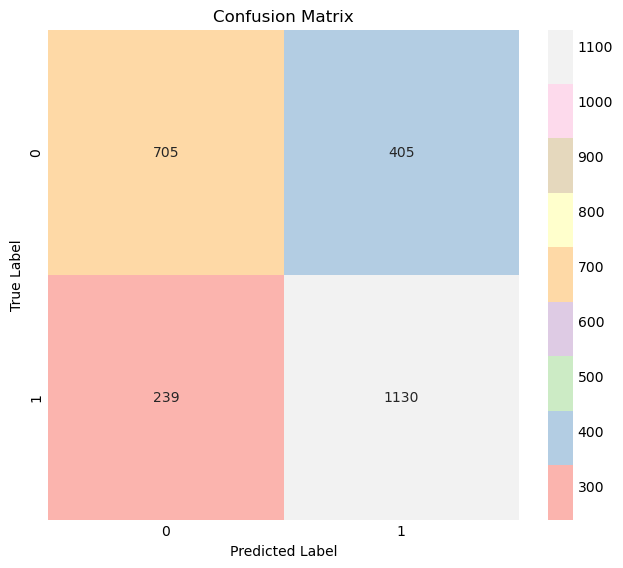


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.64      0.69      1110
           1       0.74      0.83      0.78      1369

    accuracy                           0.74      2479
   macro avg       0.74      0.73      0.73      2479
weighted avg       0.74      0.74      0.74      2479



In [236]:
# Import Libraries
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the base CatBoost model
cat_model = CatBoostClassifier(
    iterations=50,  # Number of boosting iterations
    depth=6,         # Depth of the tree
    learning_rate=0.1,
    loss_function='MultiClass',  # For multiclass classification
    verbose=200  # Print progress every 200 iterations
)

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'iterations': [50, 100],  # We are taking here the iterations is (50,100)
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5],
}

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(estimator=cat_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)  # Fit the model

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Train the best model
best_model = grid_search.best_estimator_

# Model Evaluation
train_pred = best_model.predict(x_train)
test_pred = best_model.predict(x_test)

print("\n--- Train Performance ---")
print(f"Accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"Precision: {precision_score(y_train, train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train, train_pred, average='weighted'):.4f}")

print("\n--- Test Performance ---")
print(f"Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, test_pred, average='weighted'):.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, test_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Pastel1',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, test_pred))


##### Catboost for iterations 500,1000 for checking the accuracy

0:	learn: 0.6781240	total: 10.4ms	remaining: 5.21s
200:	learn: 0.4670769	total: 1.22s	remaining: 1.82s
400:	learn: 0.4041547	total: 2.4s	remaining: 593ms
499:	learn: 0.3827739	total: 2.98s	remaining: 0us
Best Parameters: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

--- Train Performance ---
Accuracy: 0.8466
Precision: 0.8477
Recall: 0.8466

--- Test Performance ---
Accuracy: 0.7451
Precision: 0.7459
Recall: 0.7451


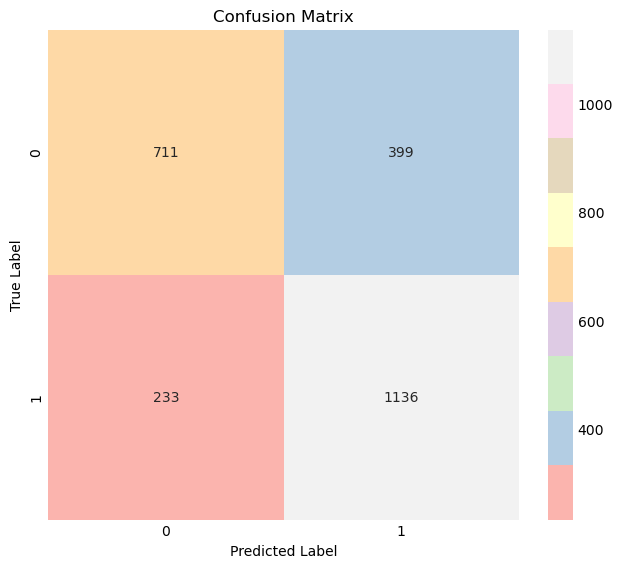


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.64      0.69      1110
           1       0.74      0.83      0.78      1369

    accuracy                           0.75      2479
   macro avg       0.75      0.74      0.74      2479
weighted avg       0.75      0.75      0.74      2479



In [237]:
# Import Libraries
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the base CatBoost model
cat_model = CatBoostClassifier(
    iterations=500,  # Number of boosting iterations
    depth=6,         # Depth of the tree
    learning_rate=0.1,
    loss_function='MultiClass',  # For multiclass classification
    verbose=200  # Print progress every 200 iterations
)

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'iterations': [500, 1000],  #Now we are taking iterations (500,1000) and checking acc.
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5],
}

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(estimator=cat_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)  # Fit the model

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Train the best model
best_model = grid_search.best_estimator_

# Model Evaluation
train_pred = best_model.predict(x_train)
test_pred = best_model.predict(x_test)

print("\n--- Train Performance ---")
print(f"Accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"Precision: {precision_score(y_train, train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train, train_pred, average='weighted'):.4f}")

print("\n--- Test Performance ---")
print(f"Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, test_pred, average='weighted'):.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, test_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Pastel1',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, test_pred))


##### Note: As comapare to iterations[50, 100] & iterations[500, 1000], iterations[50, 100] Gives better accuracy

##### Note: CATBOOST gives Better accuracy as compared to other models

In [238]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [242]:
# y_pred = final_model.predict(X_test)
# y_pred_prob = final_model.predict_proba(X_test)[:, 1]

# print(classification_report(y_test, y_pred))

# cm = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:\n", cm)

# fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
# roc_auc = auc(fpr, tpr)

# fig = go.Figure()
# fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC = {roc_auc:.2f})'))
# fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line=dict(dash='dash')))
# fig.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate',height=600,width=800,template="plotly_dark")
# fig.show()

[0.66926402 0.61581799 0.63565871 ... 0.45318712 0.60363483 0.24000366]


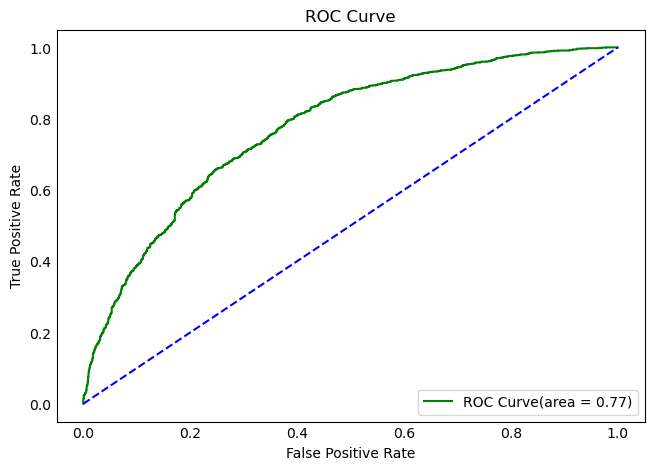

In [240]:
y_test_prob = rfc.predict_proba(x_test)[:,1]
print(y_test_prob)

# Probabilities of FPR, TPR and different thresholds of ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

auc = roc_auc_score(y_test,y_test_prob)

# Plotting ROC Curve

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='green', label = f'ROC Curve(area = {auc:.2f})')
plt.plot([0,1], [0,1], color= 'blue', linestyle= '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.grid()
plt.show()

## END